In [1]:
from langchain_openai import ChatOpenAI

In [2]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage
from langchain_core.messages import BaseMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,add_messages
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
#sys.path.insert(2, r'C:\Users\Dharmendra Vartika\LLM\langchain_document_loader')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from typing import TypedDict,Literal,Annotated
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.chat_models import init_chat_model

from langgraph.checkpoint.memory import InMemorySaver
from langgraph_swarm import create_handoff_tool, create_swarm
            # Web search tool

In [34]:
model=ChatOpenAI()
import requests
from langchain.agents import create_agent

In [78]:
def get_weather_data(city: str) -> str:
  """
  This function fetches the current weather data for a given city
  """
  url = f'https://api.weatherstack.com/current?access_key=ec07421f5107d04ec9fa783c8fcfd6c5&query={city}'

  response = requests.get(url)

  return response.json()

In [79]:
def get_currency(base_currency:str,target_currency:str)->float:
    """this functions gives the latest currency exchange rate from a given one currency to anohter currency"""
    url=f"https://v6.exchangerate-api.com/v6/5b1e43ae2540e95e7a3490fc/pair/{base_currency}/{target_currency}"
    #
    print (url)
    r=requests.get(url)
    print ('response is ',r)
    return r.json()['conversion_rate']

In [80]:
r=get_currency('SGD','INR')

https://v6.exchangerate-api.com/v6/5b1e43ae2540e95e7a3490fc/pair/SGD/INR
response is  <Response [200]>


In [81]:
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [82]:
stock_agent=create_agent(model,[get_stock_price, create_handoff_tool(agent_name="weather",description="Transfer to weather , he can help with weather report")],
                   system_prompt='you are a broker who fetches latest stock price of a given stock in  US market ',
                   name="stock")

In [83]:
weather_agent=create_agent(model,[get_weather_data, create_handoff_tool(agent_name="currency",description="Transfer to Currency, he can help with currency exchange from base currency to another")],
                   system_prompt='you works in weather department who provides the current weather  of a given city ',
                   name="weather")

In [84]:
currency_agent=create_agent(model,[get_currency, create_handoff_tool(agent_name="stock",description="Transfer to stock, he can help with stock price")],
                   system_prompt='you works in currency exchange department who provides the exchange rate from one base currency to target currecny ',
                   name="currency")

In [ ]:

config = {"configurable": {"thread_id": "1"}}

In [103]:
workflow = create_swarm(
    [weather_agent, currency_agent,stock_agent],
    default_active_agent="currency"
)
checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)

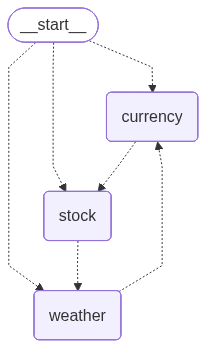

In [104]:
app

In [105]:
config = {"configurable": {"thread_id": "7"}}
state={"messages": [{"role": "user", "content": "can you get me exchange rate of SGD to INR"}]}
result =app.invoke(state,config=config)

https://v6.exchangerate-api.com/v6/5b1e43ae2540e95e7a3490fc/pair/SGD/INR
response is  <Response [200]>


In [106]:
result

{'messages': [HumanMessage(content='can you get me exchange rate of SGD to INR', additional_kwargs={}, response_metadata={}, id='4c08a023-db94-4097-882b-5d3c94f9933a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 117, 'total_tokens': 139, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CaNokOwsyS1dksfYHXnMCjzOqDcmf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--c5fd929f-335b-41b8-b159-0036b693659b-0', tool_calls=[{'name': 'get_currency', 'args': {'base_currency': 'SGD', 'target_currency': 'INR'}, 'id': 'call_418dpNee1gAg7wv4y0xQiHIC', 'type': 'tool_call'}], usage_metadata={'input_tokens': 

In [54]:
for i in result['messages']:
    i.pretty_print()

================================ Human Message =================================

can you get me weather for Mumbai
================================== Ai Message ==================================
Tool Calls:
  transfer_to_weather (call_TU9nXznkuGSFKQmPHywaW7T4)
 Call ID: call_TU9nXznkuGSFKQmPHywaW7T4
  Args:
================================= Tool Message =================================
Name: transfer_to_weather

Successfully transferred to weather
================================== Ai Message ==================================
Tool Calls:
  get_weather_data (call_GBvsdWtHaZwRVmBW342jBsJ2)
 Call ID: call_GBvsdWtHaZwRVmBW342jBsJ2
  Args:
    city: Mumbai
================================= Tool Message =================================
Name: get_weather_data

{"request": {"type": "City", "query": "Mumbai, India", "language": "en", "unit": "m"}, "location": {"name": "Mumbai", "country": "India", "region": "Maharashtra", "lat": "18.975", "lon": "72.826", "timezone_id": "Asia/Kolkata", "lo

In [109]:
config = {"configurable": {"thread_id": "8"}}
state={"messages": [{"role": "user", "content": "Give me weather report of Singapore"}]}
result =app.invoke(state,config=config)

In [110]:
result

{'messages': [HumanMessage(content='can you get me latest stock price of QSI', additional_kwargs={}, response_metadata={}, id='cdea21d4-944b-4f3c-8c44-2c50474898dc'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 116, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CaNpCc2I8VS2RhiJqWpYAVwYNXzox', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--e2c545f1-8932-49b0-b3cf-5135bb5d33c3-0', tool_calls=[{'name': 'transfer_to_stock', 'args': {}, 'id': 'call_0XRxpoEZxxV10QBo6VAi1GIg', 'type': 'tool_call'}], usage_metadata={'input_tokens': 116, 'output_tokens': 11, 'total_tokens': 127